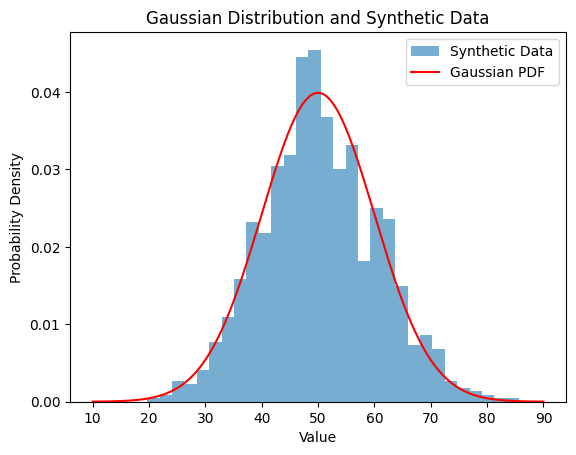

Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - loss: 0.2118
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.1491
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.1398
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


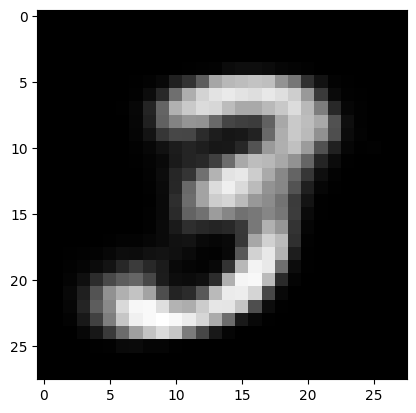

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Gaussian distribution parameters
mean=50
std=10

# 2. Sampling: generate synthetic data
data=np.random.normal(mean,std,1000)

# 3. Probability Density Function
x=np.linspace(10,90,1000)
pdf=norm.pdf(x,mean,std)

# 4. Data visualization
plt.hist(data,bins=30,density=True,alpha=.6,label="Synthetic Data")
plt.plot(x,pdf,'r',label="Gaussian PDF")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.title("Gaussian Distribution and Synthetic Data")
plt.legend()
plt.show()

# Using GMM

# using a Variational Autoencoder (VAE)
import tensorflow as tf
from tensorflow.keras import layers,Model
import matplotlib.pyplot as plt

(x,_),_=tf.keras.datasets.mnist.load_data()
x=x.reshape(-1,784).astype("float32")/255

i=layers.Input((784,))
h=layers.Dense(128,"relu")(i)
m=layers.Dense(8)(h)
v=layers.Dense(8)(h)

z=layers.Lambda(lambda a:a[0]+tf.exp(.5*a[1])*tf.random.normal(tf.shape(a[0])))([m,v])

h=layers.Dense(128,"relu")(z)
o=layers.Dense(784,"sigmoid")(h)

vae=Model(i,o)
vae.compile("adam","binary_crossentropy")
vae.fit(x,x,epochs=3,batch_size=128)

plt.imshow(vae.predict(x[:1]).reshape(28,28),cmap="gray")
plt.show()
